In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/raw/train.csv')

In [ ]:
df.head()

,Id,MSZoning,LotFrontage,LotArea,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,...,PoolQC,Alley,Fence,SaleType,SaleCondition,MoSold,YrSold,SaleDate,ListingAgent,SalePrice
0,1,RH,65.6,8734.5,Crawfor,1Story,4,5,1995,1996,...,NaN,NaN,NaN,New,Family,3,2009,2009-03-13,"Brown, Mr. James",367417.0
1,2,FV,71.6,12574.9,Edwards,SLvl,6,5,1905,1905,...,NaN,NaN,NaN,WD,Abnorml,11,2007,2007-11-25,"Brown, Mrs. Linda",275936.0
2,3,RM,70.3,7081.9,Crawfor,SFoyer,5,3,1875,1875,...,NaN,NaN,NaN,New,Partial,4,2008,2008-04-25,"Johnson, Mrs. Arjun",313758.0
3,4,C (all),74.3,5368.2,Sawyer,2Story,6,5,1891,1961,...,NaN,NaN,MnPrv,ConLD,Normal,6,2010,2010-06-05,"Miller, Ms. Anita",313006.0
4,5,FV,68.7,7022.3,OldTown,1Story,5,3,1996,1996,...,NaN,NaN,NaN,COD,Partial,11,2010,2010-11-25,"Williams, Dr. Mary",474194.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1200 non-null   int64  
 1   MSZoning       1200 non-null   str    
 2   LotFrontage    1154 non-null   float64
 3   LotArea        1200 non-null   float64
 4   Neighborhood   1200 non-null   str    
 5   HouseStyle     1200 non-null   str    
 6   OverallQual    1200 non-null   int64  
 7   OverallCond    1200 non-null   int64  
 8   YearBuilt      1200 non-null   int64  
 9   YearRemodAdd   1200 non-null   int64  
 10  ExterQual      1200 non-null   str    
 11  KitchenQual    1200 non-null   str    
 12  HeatingQC      1200 non-null   str    
 13  Foundation     1200 non-null   str    
 14  TotalBsmtSF    1200 non-null   float64
 15  MasVnrArea     1165 non-null   float64
 16  CentralAir     1200 non-null   str    
 17  GrLivArea      1200 non-null   float64
 18  FullBath       1200

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1200.0,600.500000,346.554469,1.0,300.750,600.50,900.250,1200.000000
LotFrontage,1154.0,70.349567,23.345249,21.0,54.525,70.05,87.375,141.000000
LotArea,1200.0,10022.585667,5341.410518,2170.9,6521.625,8871.45,12207.025,56458.100000
OverallQual,1200.0,5.532500,1.856560,1.0,4.000,6.00,7.000,10.000000
OverallCond,1200.0,4.455833,1.261365,1.0,4.000,4.00,5.000,8.000000
YearBuilt,1200.0,1941.386667,39.424684,1872.0,1908.000,1941.00,1976.000,2010.000000
YearRemodAdd,1200.0,1956.264167,39.339175,1872.0,1925.000,1963.00,1991.000,2010.000000
TotalBsmtSF,1200.0,1048.397667,431.911855,0.0,757.650,1050.40,1334.600,2374.300000
MasVnrArea,1165.0,84.905579,127.089944,0.0,0.000,0.00,152.100,608.600000
GrLivArea,1200.0,1522.935140,532.585278,334.0,1160.475,1505.85,1848.450,5346.992519


In [ ]:
df.isnull().mean()*100

Id                0.000000
MSZoning          0.000000
LotFrontage       3.833333
LotArea           0.000000
Neighborhood      0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
ExterQual         0.000000
KitchenQual       0.000000
HeatingQC         0.000000
Foundation        0.000000
TotalBsmtSF       0.000000
MasVnrArea        2.916667
CentralAir        0.000000
GrLivArea         0.000000
FullBath          0.000000
HalfBath          0.000000
BedroomAbvGr      0.000000
Fireplaces        0.000000
GarageType        4.666667
GarageYrBlt       4.666667
GarageArea        0.000000
PoolArea          0.000000
PoolQC           99.250000
Alley            91.500000
Fence            78.083333
SaleType          0.000000
SaleCondition     0.000000
MoSold            0.000000
YrSold            0.000000
SaleDate          0.000000
ListingAgent      0.000000
SalePrice         0.000000
dtype: float64

In [ ]:
df.isna().sum()


Id                  0
MSZoning            0
LotFrontage        46
LotArea             0
Neighborhood        0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
ExterQual           0
KitchenQual         0
HeatingQC           0
Foundation          0
TotalBsmtSF         0
MasVnrArea         35
CentralAir          0
GrLivArea           0
FullBath            0
HalfBath            0
BedroomAbvGr        0
Fireplaces          0
GarageType         56
GarageYrBlt        56
GarageArea          0
PoolArea            0
PoolQC           1191
Alley            1098
Fence             937
SaleType            0
SaleCondition       0
MoSold              0
YrSold              0
SaleDate            0
ListingAgent        0
SalePrice           0
dtype: int64

In [ ]:
df.shape

(1200, 36)

In [ ]:
df.columns

Index(['Id', 'MSZoning', 'LotFrontage', 'LotArea', 'Neighborhood',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'ExterQual', 'KitchenQual', 'HeatingQC', 'Foundation', 'TotalBsmtSF',
       'MasVnrArea', 'CentralAir', 'GrLivArea', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'Fireplaces', 'GarageType', 'GarageYrBlt', 'GarageArea',
       'PoolArea', 'PoolQC', 'Alley', 'Fence', 'SaleType', 'SaleCondition',
       'MoSold', 'YrSold', 'SaleDate', 'ListingAgent', 'SalePrice'],
      dtype='str')

<Axes: xlabel='SalePrice', ylabel='Count'>

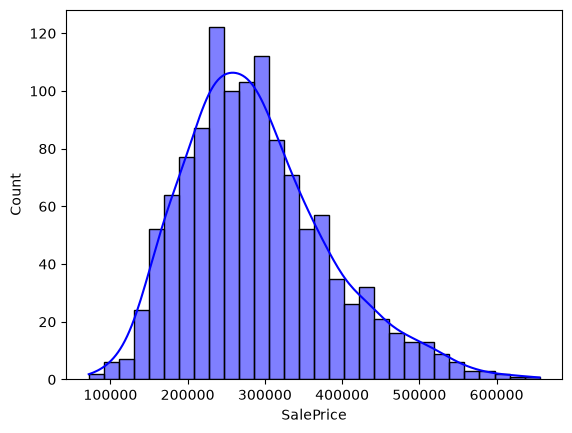

In [14]:
sns.histplot(df['SalePrice'],kde=True, color='blue', bins=30)

<Axes: xlabel='SalePrice', ylabel='Density'>

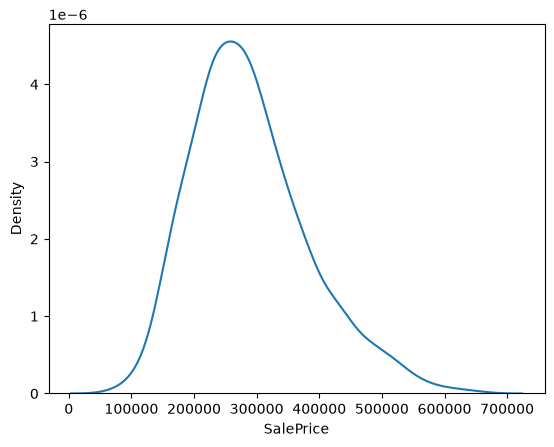

In [4]:
sns.kdeplot(df['SalePrice'])


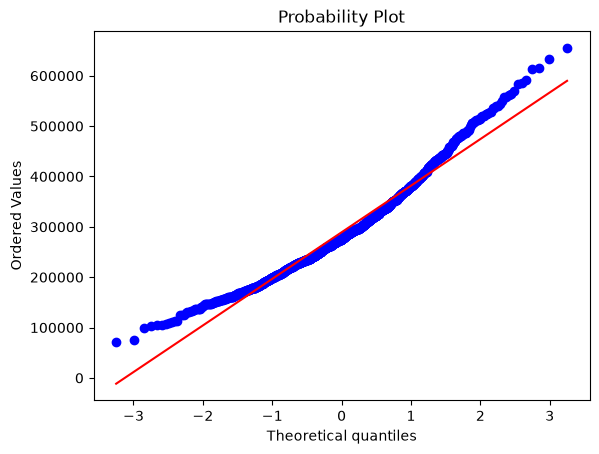

In [5]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.show()


<Axes: ylabel='GrLivArea'>

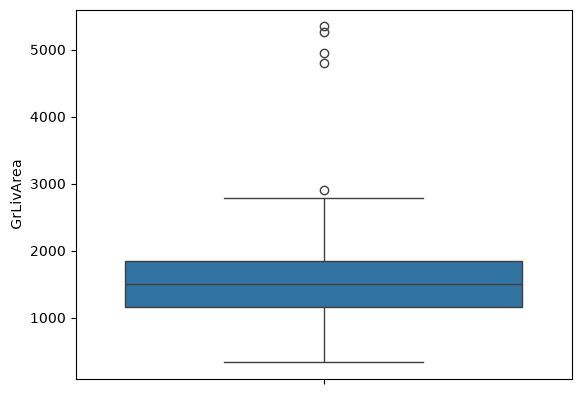

In [ ]:
sns.boxplot(df["GrLivArea"])

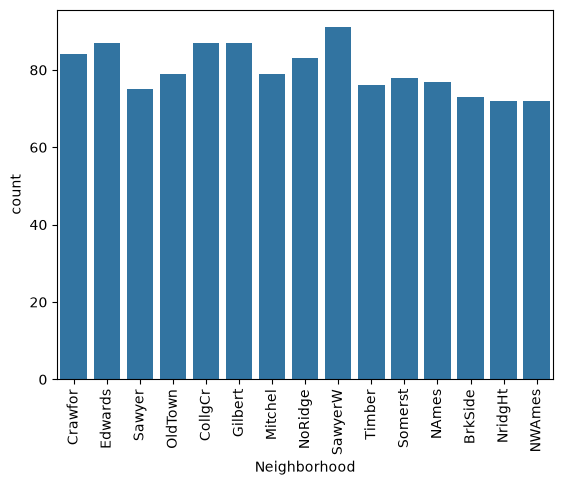

In [ ]:
sns.countplot(x = df['Neighborhood'])
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.skew(numeric_only=True).sort_values(ascending=False)

PoolArea        12.697885
LotArea          1.990431
MasVnrArea       1.492039
HalfBath         1.243644
Fireplaces       1.101011
GrLivArea        1.018393
SalePrice        0.725809
BedroomAbvGr     0.529368
OverallCond      0.068527
MoSold           0.067878
LotFrontage      0.049956
FullBath         0.044265
OverallQual      0.039918
YearBuilt        0.014649
Id               0.000000
TotalBsmtSF     -0.018510
YrSold          -0.024083
GarageArea      -0.074047
YearRemodAdd    -0.434581
GarageYrBlt     -0.933680
dtype: float64

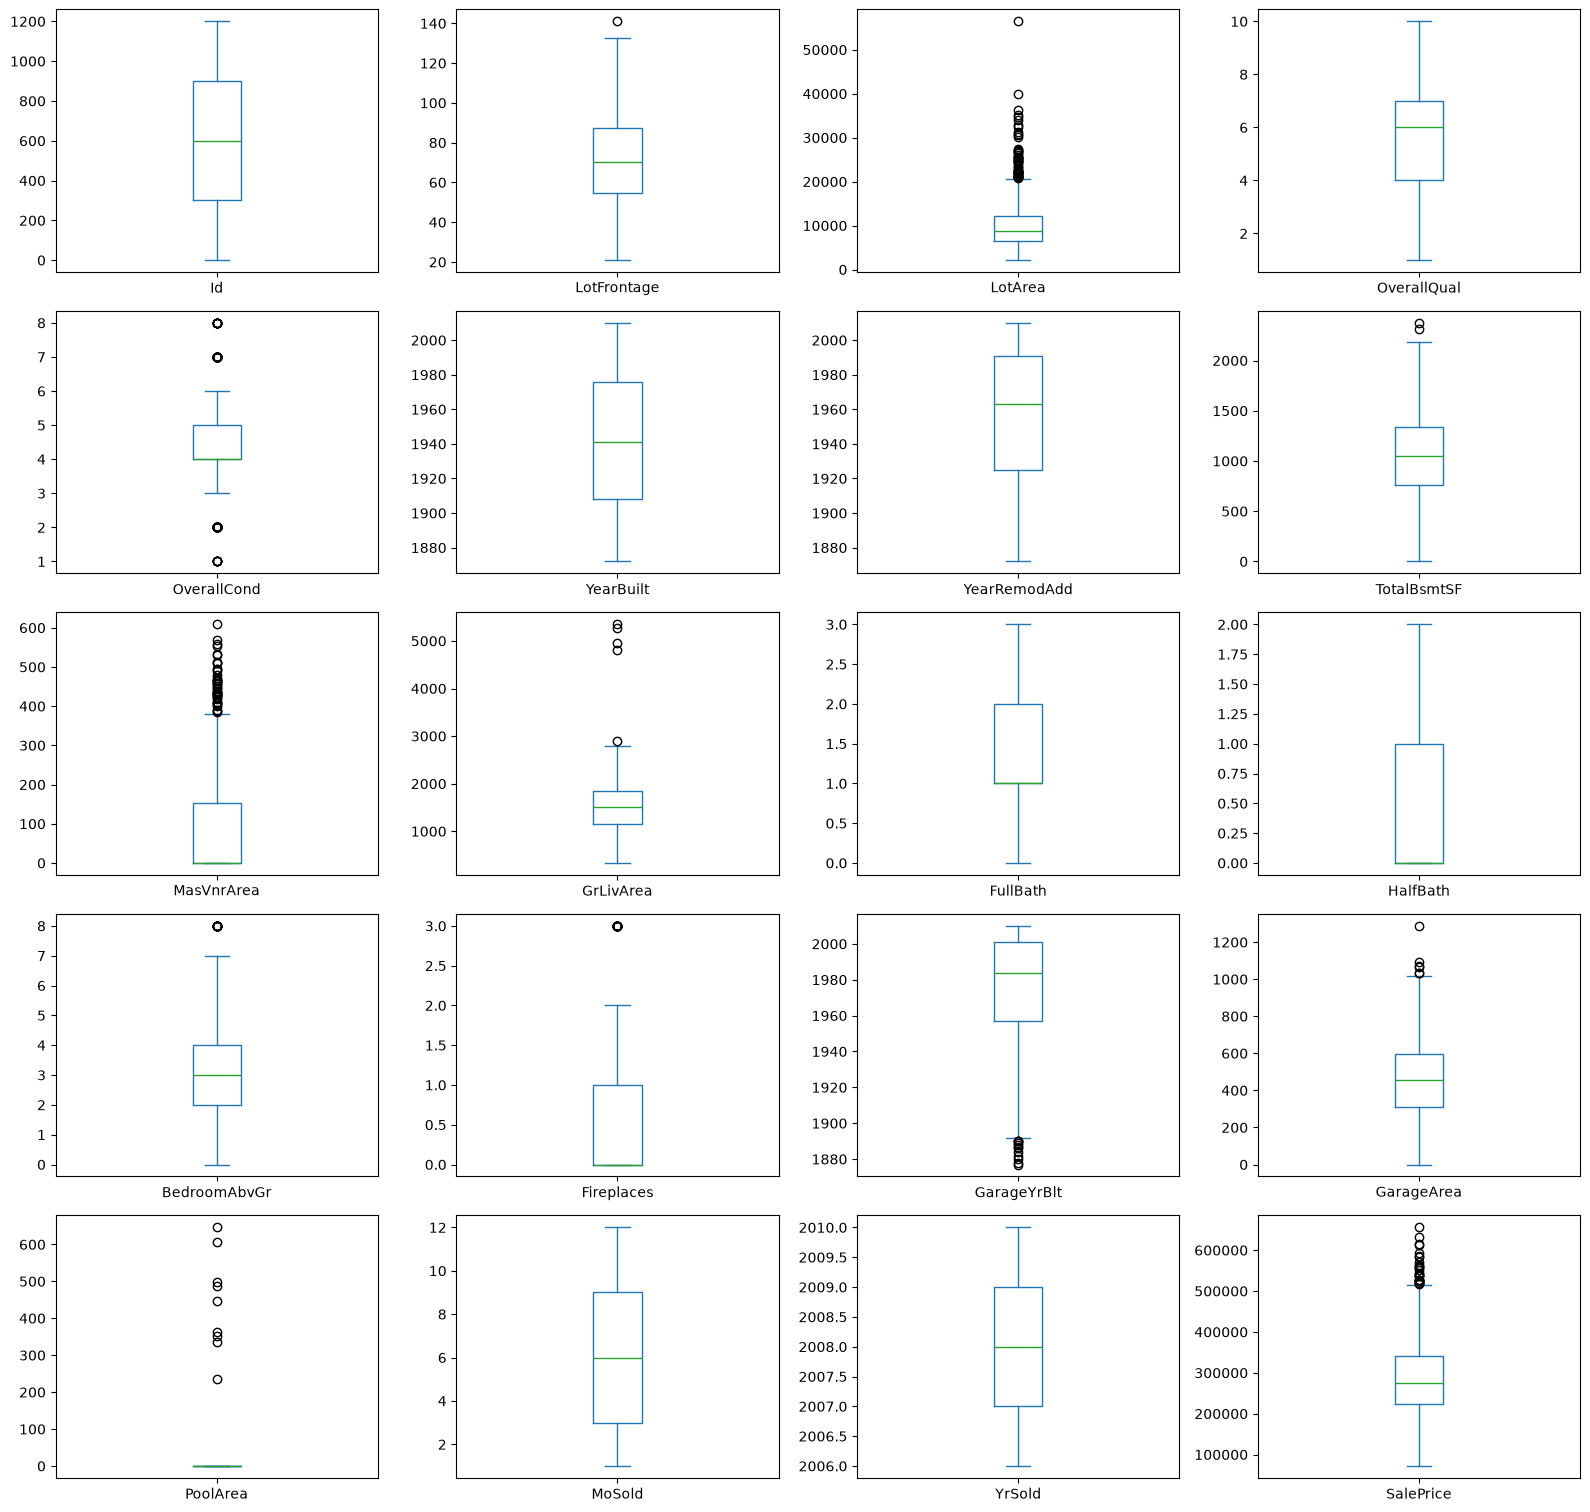

In [20]:
import math 

numeric_cols = df.select_dtypes(include="number")
numeric_cols.plot(kind="box",subplots=True,layout=(6, 4),figsize=(16, 18), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


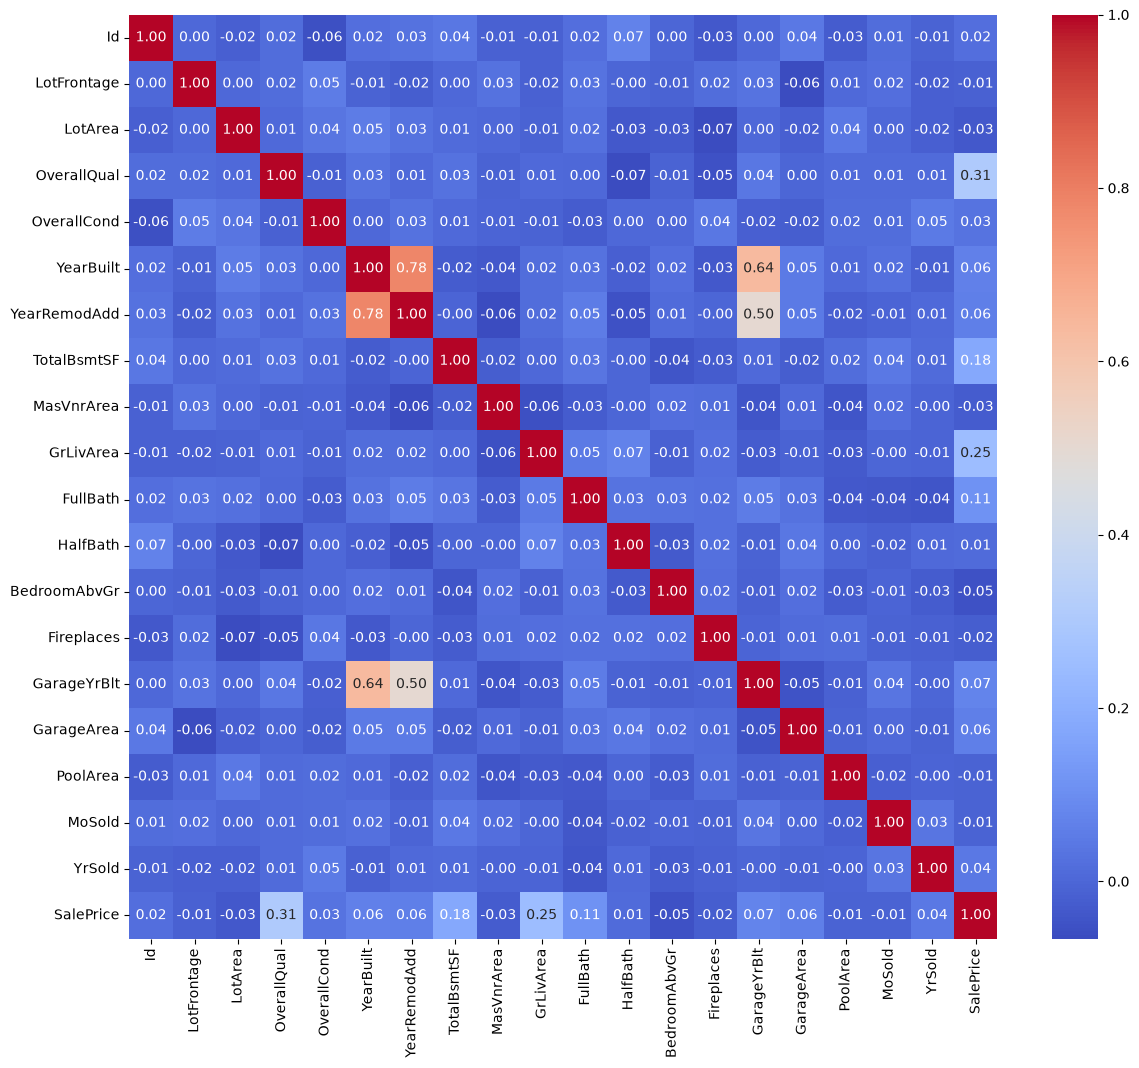

In [13]:

corr = df.select_dtypes(include = "number").drop(columns = ["Id"]).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(df.select_dtypes(include = "number").corr(),annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

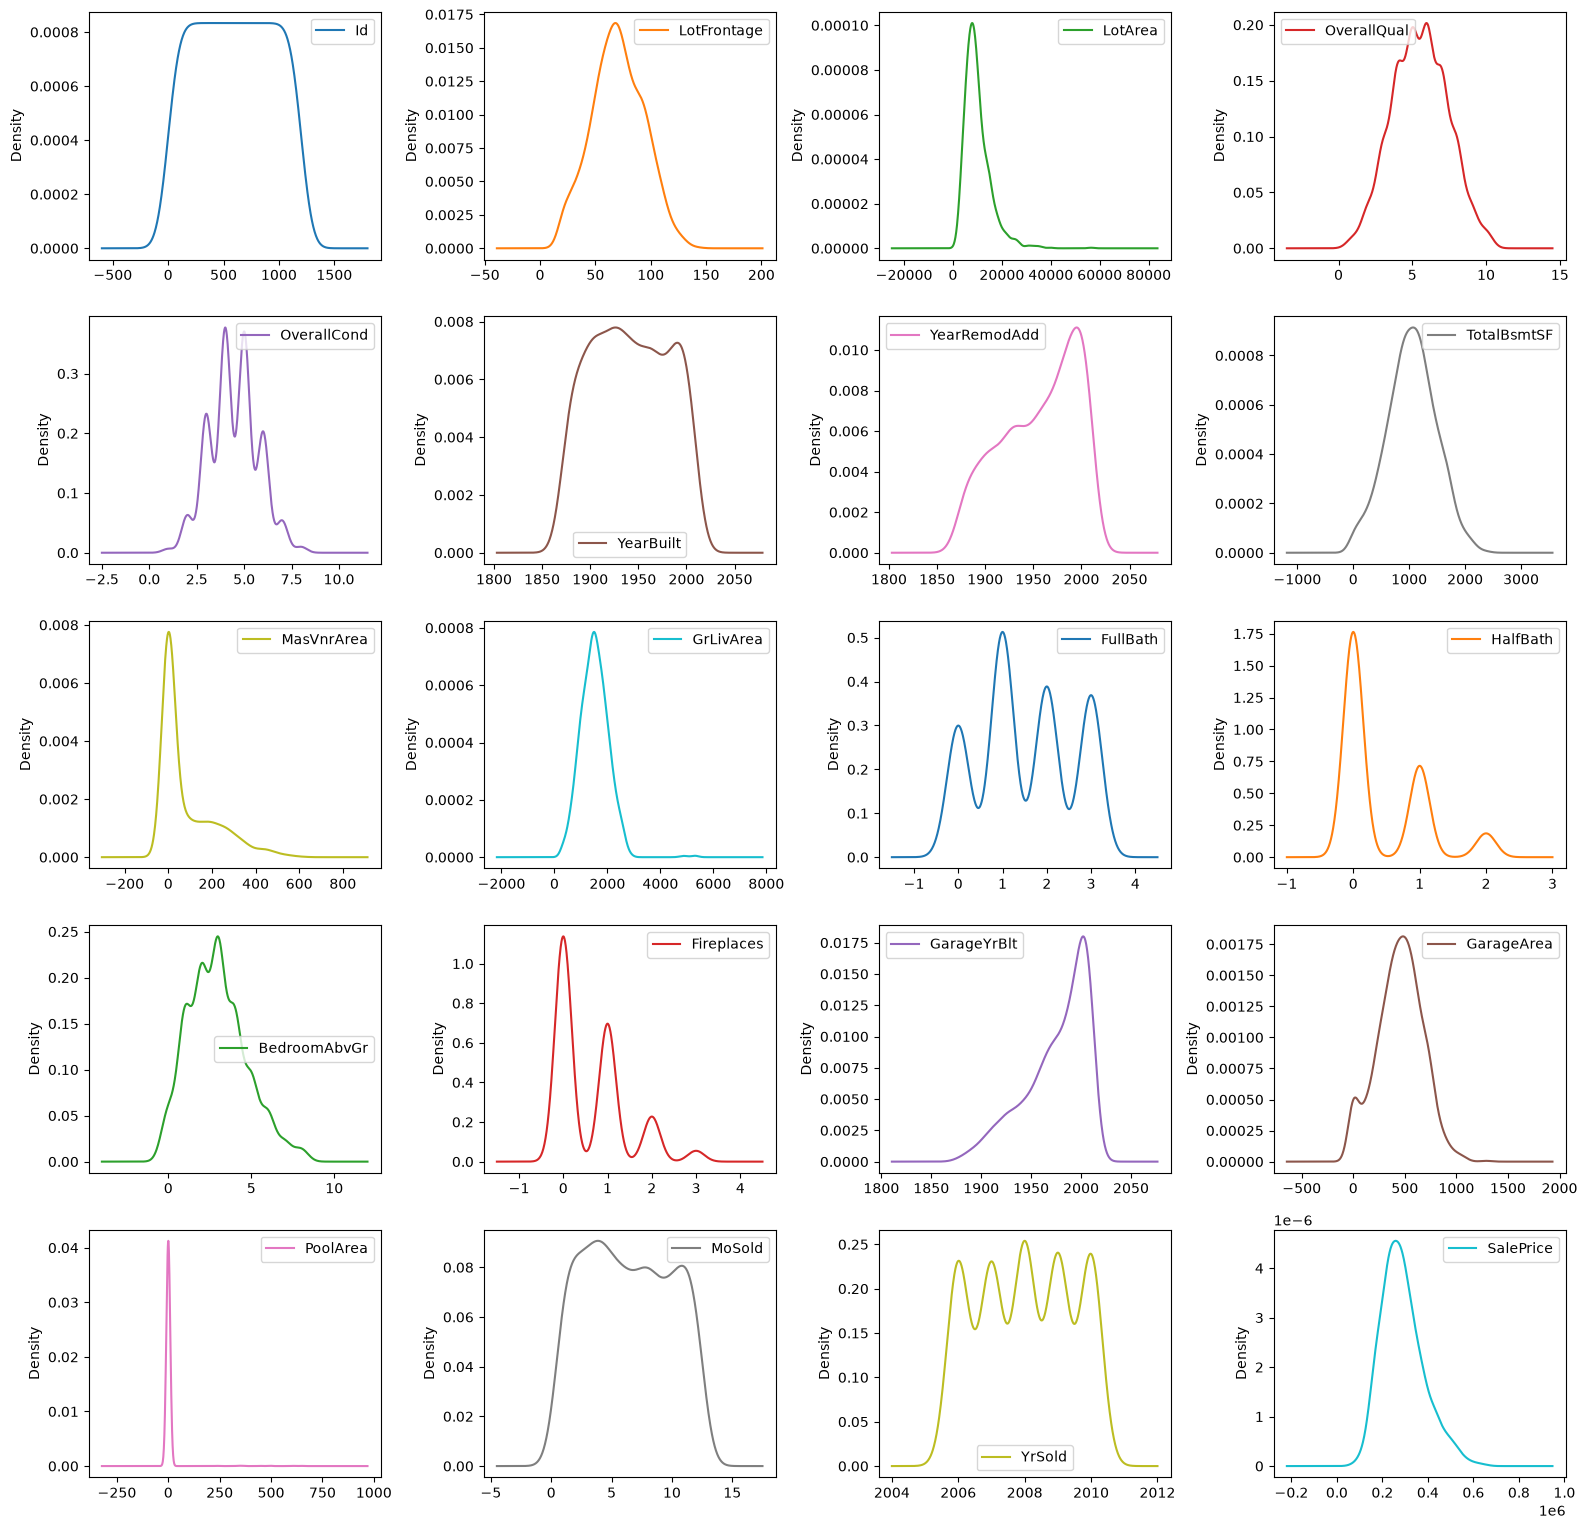

In [18]:
numeric_cols = df.select_dtypes(include="number")

numeric_cols.plot(kind="kde",subplots=True,layout=(6, 4),figsize=(16, 18), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

In [21]:
corr["SalePrice"].sort_values(ascending=False)

SalePrice       1.000000
OverallQual     0.305316
GrLivArea       0.246673
TotalBsmtSF     0.176271
FullBath        0.111398
GarageYrBlt     0.072817
YearBuilt       0.063932
GarageArea      0.062747
YearRemodAdd    0.061805
YrSold          0.044256
OverallCond     0.032809
HalfBath        0.009215
PoolArea       -0.010495
MoSold         -0.010556
LotFrontage    -0.014961
Fireplaces     -0.022457
MasVnrArea     -0.026667
LotArea        -0.033540
BedroomAbvGr   -0.050223
Name: SalePrice, dtype: float64

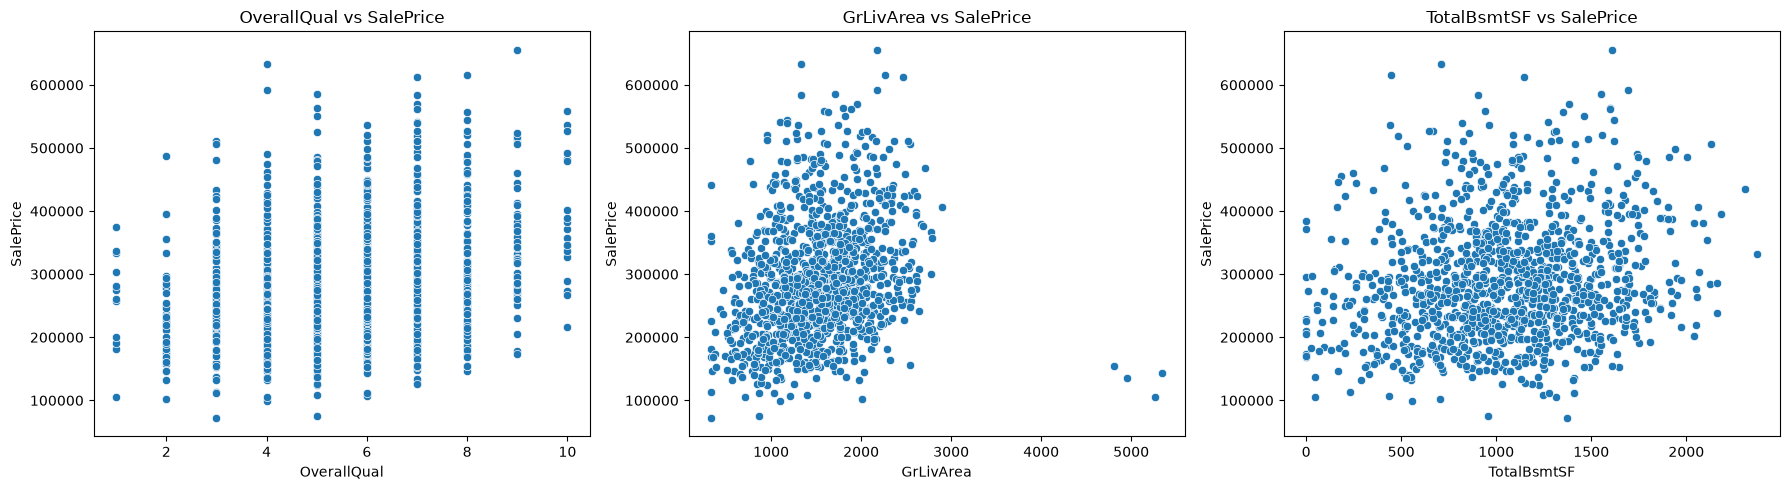

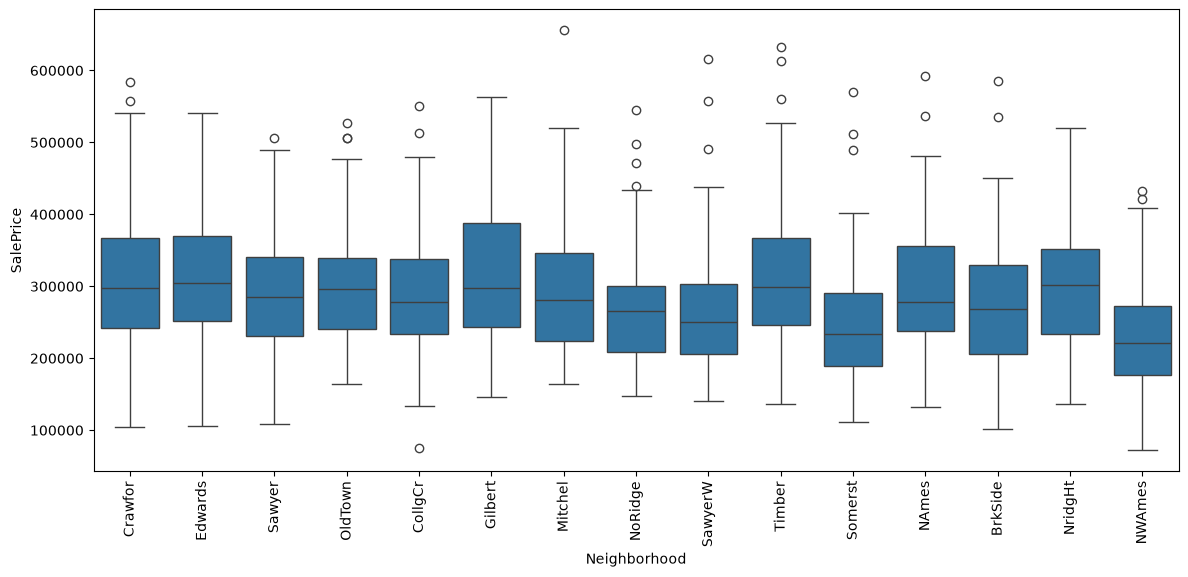

In [22]:
# Numeric vs target — scatterplots
top_numeric = ["OverallQual", "GrLivArea", "TotalBsmtSF"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, top_numeric):
    sns.scatterplot(x=df[col], y=df["SalePrice"], ax=ax)
    ax.set_title(f"{col} vs SalePrice")
plt.tight_layout()
plt.show()

# Categorical vs target — boxplots
plt.figure(figsize=(14, 6))
sns.boxplot(x=df["Neighborhood"], y=df["SalePrice"])
plt.xticks(rotation=90)
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()

cols_to_scale = ["GrLivArea", "TotalBsmtSF", "LotArea", "OverallQual"]
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

df_scaled[cols_to_scale].describe()

,GrLivArea,TotalBsmtSF,LotArea,OverallQual
count,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03
mean,-5.921189e-18,-1.687539e-16,-2.005803e-16,1.628327e-16
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00
min,-2.233315e+00,-2.428354e+00,-1.470578e+00,-2.442361e+00
25%,-6.808511e-01,-6.734450e-01,-6.557108e-01,-8.257954e-01
50%,-3.209301e-02,4.637910e-03,-2.156014e-01,2.519147e-01
75%,6.114525e-01,6.629169e-01,4.091335e-01,7.907698e-01
max,7.183172e+00,3.071125e+00,8.697117e+00,2.407335e+00
